In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/nextgen_nlp_final")
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

NER_INPUT_PATH = ARTIFACTS_DIR / "ner_input_articles.parquet"

df_sent = pd.read_parquet(NER_INPUT_PATH)

print("Shape:", df_sent.shape)
df_sent.head()

Shape: (33765, 6)


,date,title_clean,clean_text,topic,topic_name,industry_label
0,2024-03-13 00:00:00+00:00,Best AI Prompts for Business Risk Management,ManagementPrompt: Identify and prioritize pote...,4,AI cybersecurity,Cybersecurity
1,2023-07-26 00:00:00+00:00,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,"July 26, 2023 Finance Bullfrog AI Holdings Inc...",0,AI chips and GPUs,AI Infrastructure
2,2025-01-17 00:00:00+00:00,4 Principles to Help Federal Agencies Adopt AI...,"Source: SolarWinds, “Navigating the AI Revolut...",4,AI cybersecurity,Cybersecurity
3,2024-02-13 00:00:00+00:00,2 Artificial Intelligence (AI) Stocks to Buy a...,"February 13, 2024 at 9:13 AM·4 min readArtific...",0,AI chips and GPUs,AI Infrastructure
4,2022-11-09 00:00:00+00:00,Silicon Photonics Market to Present Revenue Op...,"November 9, 2022, 9:02 AM·5 min readSkyQuest T...",0,AI chips and GPUs,AI Infrastructure


In [ ]:
from transformers import pipeline
import torch

print("Torch CUDA:", torch.cuda.is_available())

Torch CUDA: True


In [ ]:
from transformers import pipeline
import torch

MODEL_PATH = "/content/drive/MyDrive/nextgen_nlp_final/models/ai_sentiment_model"

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

sentiment_pipe = pipeline(
    "text-classification",
    model=MODEL_PATH,
    tokenizer=MODEL_PATH,
    device=0
)

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
sample_texts = df_sent["clean_text"].sample(5, random_state=42).astype(str).str[:1500].tolist()

for i, txt in enumerate(sample_texts, 1):
    pred = sentiment_pipe(txt, truncation=True, max_length=512)
    print(f"\n===== SAMPLE {i} =====")
    print(pred)


===== SAMPLE 1 =====
[{'label': 'positive', 'score': 0.6331921219825745}]

===== SAMPLE 2 =====
[{'label': 'positive', 'score': 0.9255642294883728}]

===== SAMPLE 3 =====
[{'label': 'neutral', 'score': 0.6862485408782959}]

===== SAMPLE 4 =====
[{'label': 'positive', 'score': 0.5447525382041931}]

===== SAMPLE 5 =====
[{'label': 'positive', 'score': 0.6442269086837769}]


In [ ]:
def map_sentiment_label(label):
    label = label.lower()
    if label == "neutral":
        return "neutral"
    return label

In [ ]:
texts = df_sent["clean_text"].fillna("").astype(str).str[:2000].tolist()

batch_size = 64
sentiment_results = []

for start in range(0, len(texts), batch_size):
    end = min(start + batch_size, len(texts))
    batch = texts[start:end]

    outputs = sentiment_pipe(
        batch,
        truncation=True,
        max_length=512
    )

    sentiment_results.extend(outputs)

    if start % 5000 == 0:
        print(f"processed: {start} -> {end}")

processed: 0 -> 64


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
df_sent["sentiment_score"] = [x["score"] for x in sentiment_results]


In [ ]:
df_sent = df_sent.drop(columns=["sentiment_raw"])

In [ ]:
df_sent.head()

,date,title_clean,clean_text,topic,topic_name,industry_label,sentiment_score,sentiment
0,2024-03-13 00:00:00+00:00,Best AI Prompts for Business Risk Management,ManagementPrompt: Identify and prioritize pote...,4,AI cybersecurity,Cybersecurity,0.536847,neutral
1,2023-07-26 00:00:00+00:00,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,"July 26, 2023 Finance Bullfrog AI Holdings Inc...",0,AI chips and GPUs,AI Infrastructure,0.574204,positive
2,2025-01-17 00:00:00+00:00,4 Principles to Help Federal Agencies Adopt AI...,"Source: SolarWinds, “Navigating the AI Revolut...",4,AI cybersecurity,Cybersecurity,0.647027,neutral
3,2024-02-13 00:00:00+00:00,2 Artificial Intelligence (AI) Stocks to Buy a...,"February 13, 2024 at 9:13 AM·4 min readArtific...",0,AI chips and GPUs,AI Infrastructure,0.489629,neutral
4,2022-11-09 00:00:00+00:00,Silicon Photonics Market to Present Revenue Op...,"November 9, 2022, 9:02 AM·5 min readSkyQuest T...",0,AI chips and GPUs,AI Infrastructure,0.779577,positive


In [ ]:
ARTIFACTS_DIR = Path("/content/drive/MyDrive/nextgen_nlp_final/artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

df_sent.to_parquet(ARTIFACTS_DIR / "article_sentiment.parquet", index=False)

print("Saved:", ARTIFACTS_DIR / "article_sentiment.parquet")

Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/article_sentiment.parquet


In [ ]:
topic_sentiment = (
    df_sent
    .groupby(["topic_name", "sentiment"])
    .size()
    .reset_index(name="count")
    .sort_values(["topic_name", "count"], ascending=[True, False])
)

topic_sentiment.head(20)

,topic_name,sentiment,count
2,AI adoption in small businesses,positive,634
1,AI adoption in small businesses,neutral,504
0,AI adoption in small businesses,negative,7
5,AI and crypto / Web3,positive,802
4,AI and crypto / Web3,neutral,704
3,AI and crypto / Web3,negative,8
8,AI chips and GPUs,positive,4576
7,AI chips and GPUs,neutral,3437
6,AI chips and GPUs,negative,75
10,AI company governance events,neutral,741


In [ ]:
topic_sentiment["total"] = (
    topic_sentiment
    .groupby("topic_name")["count"]
    .transform("sum")
)

topic_sentiment["pct"] = topic_sentiment["count"] / topic_sentiment["total"]

In [ ]:
top_topics = (
    df_sent["topic_name"]
    .value_counts()
    .head(12)
    .index
)

topic_sentiment_top = topic_sentiment[
    topic_sentiment["topic_name"].isin(top_topics)
]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

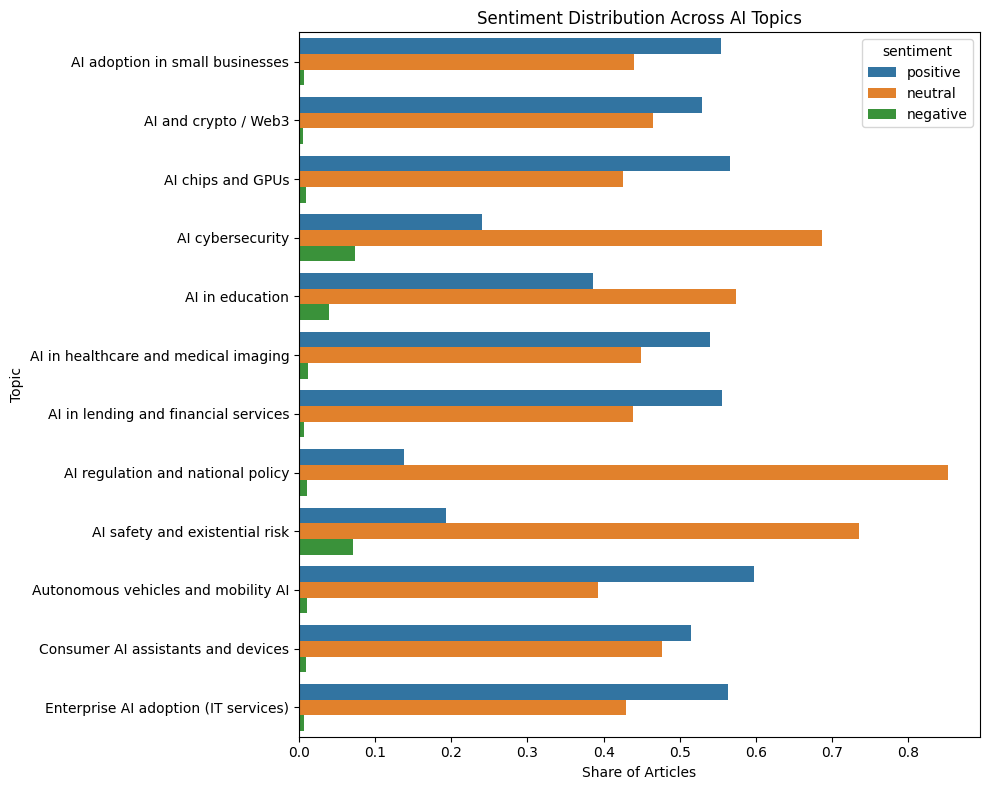

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=topic_sentiment_top,
    x="pct",
    y="topic_name",
    hue="sentiment"
)

plt.title("Sentiment Distribution Across AI Topics")
plt.xlabel("Share of Articles")
plt.ylabel("Topic")

plt.tight_layout()
plt.show()